<a href="https://colab.research.google.com/github/Kukarki/karki/blob/main/COMP4353_DataMining_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

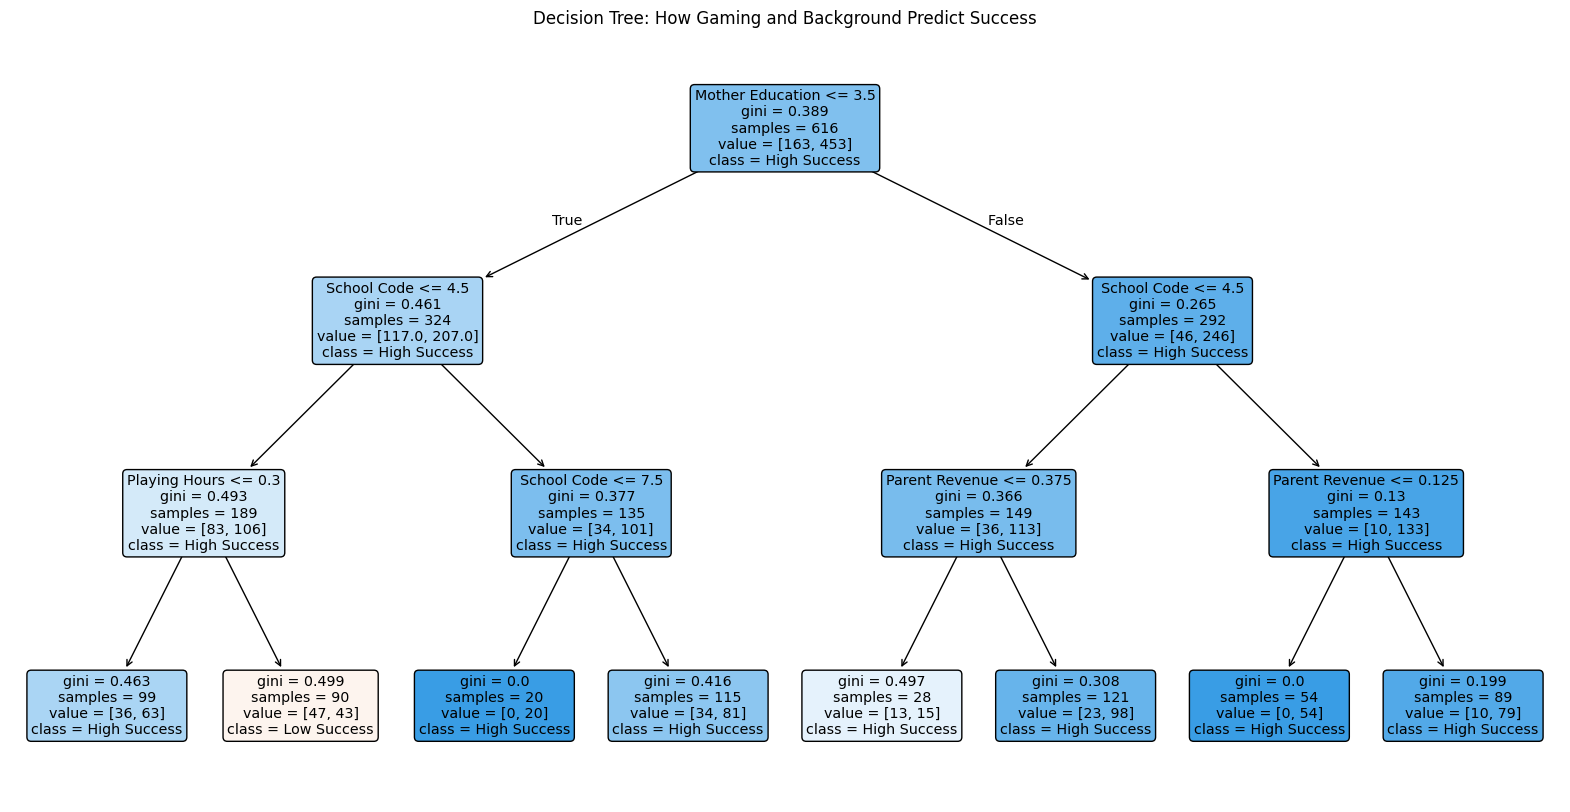

In [9]:
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Low Success', 'High Success'], filled=True, rounded=True)
plt.title("Decision Tree: How Gaming and Background Predict Success")
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# 1. Discretization: Turn continuous Grade into "High" (1) or "Low" (0)
# We use 0.5 as the cutoff since the data is normalized 0-1
df['Success_Label'] = (df['Grade'] > 0.5).astype(int)

# 2. Define Features (X) and Target (y)
# Drop the original 'Grade' and our new 'Success_Label' from X
X = df.drop(columns=['Grade', 'Success_Label'])
y = df['Success_Label']

# 3. Split data: 80% for training the AI, 20% to test if it's right
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
clf = DecisionTreeClassifier(max_depth=3) # Limit depth so the tree stays readable
clf.fit(X_train, y_train)

# 5. Check Accuracy
y_pred = clf.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Model Accuracy: 72.08%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.52      0.27      0.36        44
           1       0.76      0.90      0.82       110

    accuracy                           0.72       154
   macro avg       0.64      0.59      0.59       154
weighted avg       0.69      0.72      0.69       154



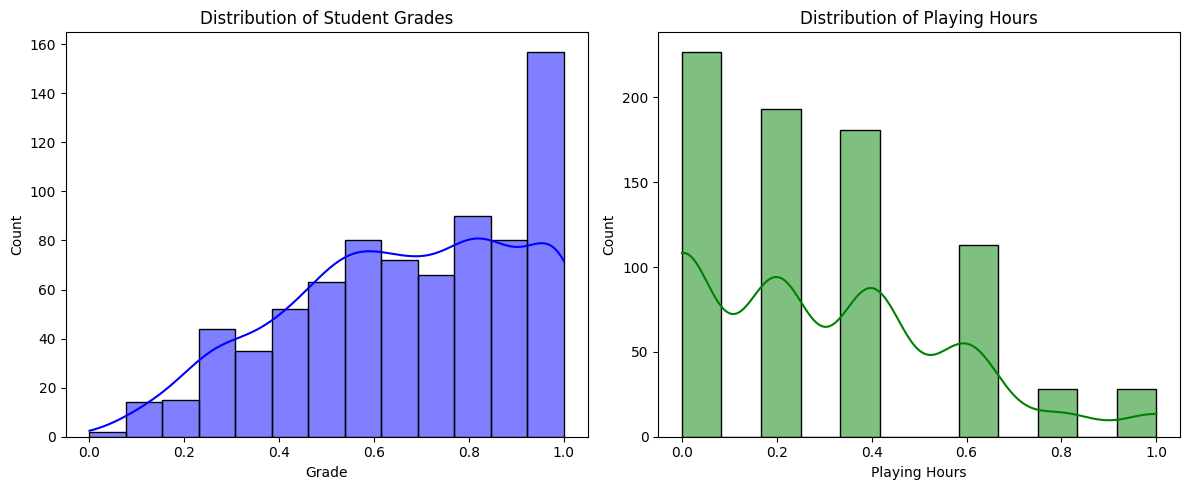

In [7]:
# Visualize the distribution of Grades and Playing Hours
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Grade'], kde=True, color='blue')
plt.title('Distribution of Student Grades')

plt.subplot(1, 2, 2)
sns.histplot(df['Playing Hours'], kde=True, color='green')
plt.title('Distribution of Playing Hours')

plt.tight_layout()
plt.show()

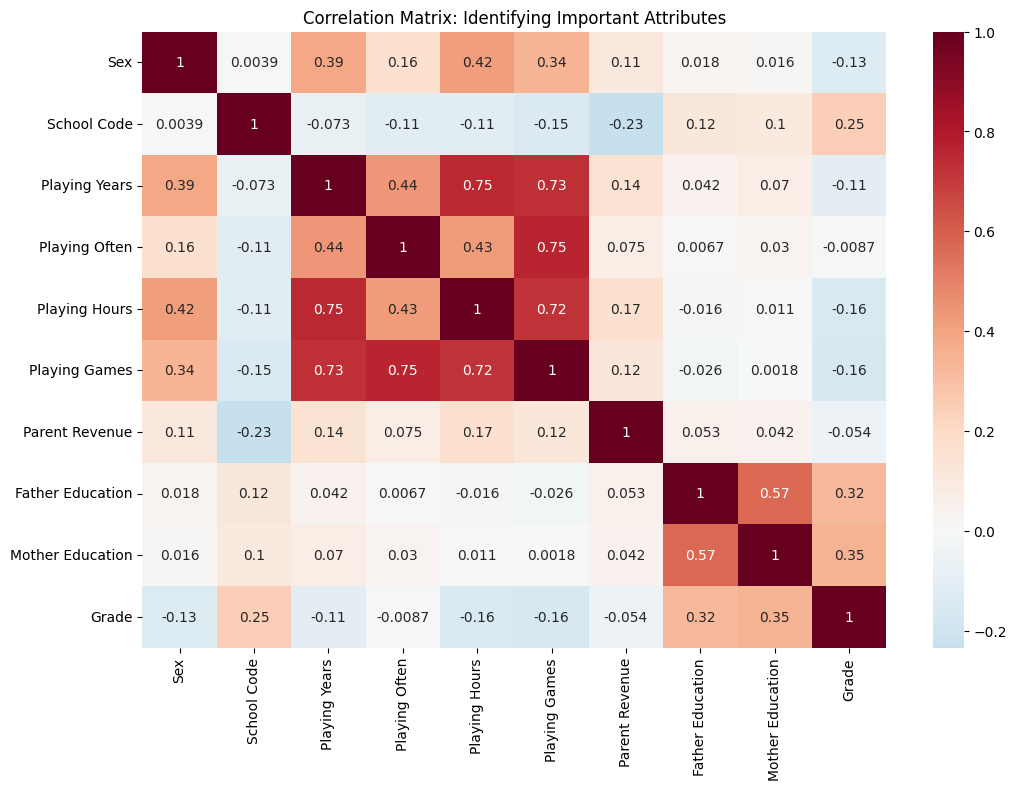

--- Correlation with Student Grade ---
Grade               1.000000
Mother Education    0.352787
Father Education    0.320257
School Code         0.249971
Playing Games       0.162101
Playing Hours       0.158699
Sex                 0.134904
Playing Years       0.107480
Parent Revenue      0.054419
Playing Often       0.008689
Name: Grade, dtype: float64


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate how every column relates to the others
corr = df.corr()

# 2. Create a "Heatmap" to see it visually
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix: Identifying Important Attributes')
plt.show()

# 3. Data Reduction: Identify columns with very low correlation to 'Grade'
# We look at the 'Grade' column specifically.
target_corr = corr['Grade'].abs().sort_values(ascending=False)
print("--- Correlation with Student Grade ---")
print(target_corr)

In [5]:
# 1. Function to fix the double dots and non-numeric junk
def clean_currency(x):
    if isinstance(x, str):
        # Remove anything that isn't a digit or a single decimal point
        import re
        x = re.sub(r'[^0-9.]', '', x)
        # Fix the double dot error '92..00' -> '92.00'
        if '..' in x:
            x = x.replace('..', '.')
    return x

# 2. Apply the fix to the columns that might have typos
cols_to_fix = ['Playing Hours', 'Parent Revenue', 'Grade']
for col in cols_to_fix:
    df[col] = df[col].apply(clean_currency).astype(float)

# 3. Now that they are clean floats, try the Normalization again
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[cols_to_fix] = scaler.fit_transform(df[cols_to_fix])

# 4. Check the result
print("--- Fixed and Normalized Data ---")
print(df[cols_to_fix].head())

--- Fixed and Normalized Data ---
   Playing Hours  Parent Revenue     Grade
0            0.2            1.00  0.664179
1            0.2            0.25  0.746269
2            0.0            0.25  0.701493
3            0.2            0.50  0.179104
4            0.4            0.25  0.776119


In [1]:
from google.colab import userdata
import os

# Link your token from the Secrets tab
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# Download the specific dataset you chose
!kaggle datasets download -d deadier/play-games-and-success-in-students

# Unzip the file so we can use the CSV
!unzip -o play-games-and-success-in-students.zip

# Load and look at the data
import pandas as pd
df = pd.read_csv('gameandgrade_new.csv')

# Show the first 5 rows to make sure it's correct
df.head()

Dataset URL: https://www.kaggle.com/datasets/deadier/play-games-and-success-in-students
License(s): apache-2.0
100% 4.15k/4.15k [00:00<00:00, 9.34MB/s]

Archive:  play-games-and-success-in-students.zip
  inflating: gameandgrade.csv        


FileNotFoundError: [Errno 2] No such file or directory: 'gameandgrade_new.csv'

In [2]:
import pandas as pd

# Load the data with the correct filename
df = pd.read_csv('gameandgrade.csv')

# This will show the top 5 rows of your project data
df.head()

,Sex,School Code,Playing Years,Playing Often,Playing Hours,Playing Games,Parent Revenue,Father Education,Mother Education,Grade
0,0,1,1,2,1,1,4,4,5,77.50
1,1,1,1,3,1,1,1,3,3,83.00
2,0,1,0,0,0,0,1,3,3,80.00
3,0,1,3,5,1,1,2,2,3,45.00
4,1,1,1,1,2,1,1,3,4,85.00


ValueError: could not convert string to float: '92..00'

In [3]:
# Check for missing values in each column
print("--- Missing Values Count ---")
print(df.isnull().sum())

# Check the data types (to see what is text vs numbers)
print("\n--- Data Types ---")
print(df.info())

--- Missing Values Count ---
Sex                 0
School Code         0
Playing Years       0
Playing Often       0
Playing Hours       0
Playing Games       0
Parent Revenue      0
Father Education    0
Mother Education    0
Grade               0
dtype: int64

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Sex               770 non-null    int64 
 1   School Code       770 non-null    int64 
 2   Playing Years     770 non-null    int64 
 3   Playing Often     770 non-null    int64 
 4   Playing Hours     770 non-null    int64 
 5   Playing Games     770 non-null    int64 
 6   Parent Revenue    770 non-null    int64 
 7   Father Education  770 non-null    int64 
 8   Mother Education  770 non-null    int64 
 9   Grade             770 non-null    object
dtypes: int64(9), object(1)
memory usage: 60.3+ KB
None
